In [266]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [267]:
df = pd.read_csv("insurance.csv")

In [268]:
df 

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [269]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [270]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [271]:
df.shape

(1338, 7)

In [272]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [273]:
x = df[['age', 'bmi', 'children', 'sex', 'smoker', 'region']]
x = pd.get_dummies(x, columns= ['sex', 'smoker', 'region'], drop_first= True)
y = df['charges']

In [274]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (1338, 8)
y shape: (1338,)


In [275]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size= 0.2 , random_state = 42)

In [276]:
lr = LinearRegression()

In [277]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [278]:
y_pred = lr.predict(X_test)
y_pred

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084137, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673494, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303303, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [279]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [280]:
X_test

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
764,45,25.175,2,False,False,False,False,False
887,36,30.020,0,False,False,True,False,False
890,64,26.885,0,False,True,True,False,False
1293,46,25.745,3,True,False,True,False,False
259,19,31.920,0,True,True,True,False,False
...,...,...,...,...,...,...,...,...
109,63,35.090,0,True,True,False,True,False
575,58,27.170,0,False,False,True,False,False
535,38,28.025,1,True,False,False,False,False
543,54,47.410,0,False,True,False,True,False


In [281]:
r2 = r2_score(y_test, y_pred)
r2


0.7835929767120723

In [282]:
mse = mean_squared_error(y_test , y_pred)
mse

33596915.85136147

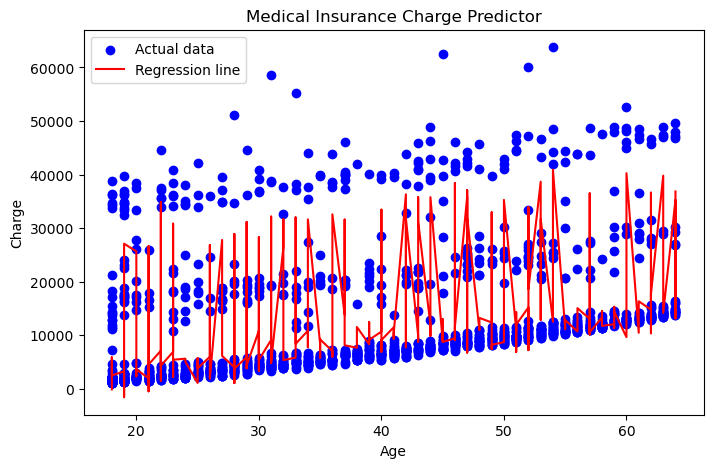

In [ ]:
import numpy as np


sort_idx = np.argsort(X_test['age'].values)
age_sorted = X_test['age'].values[sort_idx]
pred_sorted = lr.predict(X_test)[sort_idx]

plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['charges'], color='blue', label='Actual data')
plt.plot(age_sorted, pred_sorted, color='red', label='Regression line')
plt.xlabel('Age')
plt.ylabel('Charge')
plt.title('Medical Insurance Charge Predictor')
plt.legend()
plt.show()

In [293]:
pickle.dump(lr, open("model.pkl","wb"))